In [1]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)
print(tf.config.list_physical_devices())

2.21.0
2.4.4
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
# =========================
# 1. IMPORTS
# =========================
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks, layers, models

# Speed-up on GPU when available
if tf.config.list_physical_devices("GPU"):
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled")
else:

    print("Running on CPU")

Running on CPU


In [3]:
# =========================
# 2. LOAD DATASET (RAW SPLIT FOR MULTI-MODEL TRAINING)
# =========================
DATASET_PATH = Path(
    r"C:\Users\deept\Fpxnet Dropbox\xafolo xafolo\shareit\course\Deepu\tea project\advanced images"
)

SEED = 123
VAL_SPLIT = 0.2

# Fixed class order requested by user
class_names = [
    "green_tea",
    "black_tea",
    "oolong_tea",
    "chamomile_tea",
    "peppermint_tea",
    "ginger_tea",
    "hibiscus_tea",
    "rooibos_tea",
    "lavender_tea",
    "matcha_tea",
    "chai_tea",
    "turmeric_tea",
    "rosehip_tea",
    "blueberry_tea",
    "raspberry_tea",
    "kukicha_tea",
    "genmaicha_tea",
    "lemon_tea",
]
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

missing_classes = [c for c in class_names if not (DATASET_PATH / c).is_dir()]
if missing_classes:
    raise ValueError(f"Missing class folders: {missing_classes}")

print("Using classes:", class_names)
print("Num classes:", len(class_names))

# Gather all image paths and labels
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
file_paths = []
labels = []
for cname in class_names:
    class_dir = DATASET_PATH / cname
    class_files = [
        p
        for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in extensions
    ]
    file_paths.extend([str(p) for p in class_files])
    labels.extend([class_to_idx[cname]] * len(class_files))

file_paths = np.array(file_paths)
labels = np.array(labels, dtype=np.int32)

if len(file_paths) == 0:
    raise ValueError("No images found. Check DATASET_PATH and class folders.")

# Stratified split guarantees class representation in validation set
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths,
    labels,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=labels,
)


def load_raw_image(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)


raw_train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
raw_train_ds = raw_train_ds.shuffle(
    len(train_paths), seed=SEED, reshuffle_each_iteration=True
)
raw_train_ds = raw_train_ds.map(load_raw_image, num_parallel_calls=tf.data.AUTOTUNE)

raw_val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
raw_val_ds = raw_val_ds.map(load_raw_image, num_parallel_calls=tf.data.AUTOTUNE)

# Quick sanity check: every class should appear in validation
val_counts = np.bincount(val_labels, minlength=len(class_names))
coverage_df = pd.DataFrame(
    {
        "class": class_names,
        "val_count": val_counts,
    }
)
print("Validation coverage by class:")
display(coverage_df)

Using classes: ['green_tea', 'black_tea', 'oolong_tea', 'chamomile_tea', 'peppermint_tea', 'ginger_tea', 'hibiscus_tea', 'rooibos_tea', 'lavender_tea', 'matcha_tea', 'chai_tea', 'turmeric_tea', 'rosehip_tea', 'blueberry_tea', 'raspberry_tea', 'kukicha_tea', 'genmaicha_tea', 'lemon_tea']
Num classes: 18
Validation coverage by class:


,class,val_count
0,green_tea,60
1,black_tea,60
2,oolong_tea,60
3,chamomile_tea,60
4,peppermint_tea,60
5,ginger_tea,60
6,hibiscus_tea,60
7,rooibos_tea,60
8,lavender_tea,60
9,matcha_tea,60


In [4]:
# =========================
# 3. SAVE CLASS INFO
# =========================
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['green_tea', 'black_tea', 'oolong_tea', 'chamomile_tea', 'peppermint_tea', 'ginger_tea', 'hibiscus_tea', 'rooibos_tea', 'lavender_tea', 'matcha_tea', 'chai_tea', 'turmeric_tea', 'rosehip_tea', 'blueberry_tea', 'raspberry_tea', 'kukicha_tea', 'genmaicha_tea', 'lemon_tea']


In [5]:
# =========================
# 5. DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.12),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.2),
    ]
)

In [ ]:
# =========================
# 4. DEFINE HELPER FUNCTIONS AND TRAIN_HYBRID_MODEL
# =========================
AUTOTUNE = tf.data.AUTOTUNE


def build_backbone(backbone_name, img_size):
    """Build a backbone model without embedded preprocessing layers."""
    if "EfficientNetV2S" in backbone_name:
        return tf.keras.applications.EfficientNetV2S(
            input_shape=(*img_size, 3),
            include_top=False,
            include_preprocessing=True,
            weights="imagenet",
        )
    if "MobileNetV3Small" in backbone_name:
        return tf.keras.applications.MobileNetV3Small(
            input_shape=(*img_size, 3),
            include_top=False,
            include_preprocessing=True,
            weights="imagenet",
        )
    raise ValueError(
        f"Unknown backbone: {backbone_name}. Supported: EfficientNetV2S, MobileNetV3Small"
    )


def make_dataset(paths, labels, spec, training=True):
    """Build a dataset for the hybrid model input size."""

    def preprocess(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, spec["img_size"])
        img = tf.cast(img, tf.float32)
        return img, tf.cast(label, tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(min(len(paths), 1000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(spec["batch_size"])
    ds = ds.prefetch(buffer_size=spec["prefetch"])
    return ds


def get_branch_dropout(spec, backbone_name):
    """Return a branch-specific dropout rate when provided."""
    return spec.get("branch_dropouts", {}).get(backbone_name, spec["dropout"])


def get_branch_units(spec, backbone_name):
    """Return a branch-specific projection width when provided."""
    return spec.get("branch_units_by_backbone", {}).get(
        backbone_name, spec["branch_units"]
    )


def get_unfreeze_last(spec, backbone_name):
    """Return a branch-specific fine-tuning depth when provided."""
    return spec.get("unfreeze_last_by_backbone", {}).get(
        backbone_name, spec.get("unfreeze_last", 20)
    )


def unfreeze_backbone_tail(backbone, unfreeze_last):
    """Unfreeze the last non-BatchNorm layers in a backbone for fine-tuning."""
    backbone.trainable = True
    for layer in backbone.layers:
        layer.trainable = False

    trainable_count = 0
    for layer in reversed(backbone.layers):
        if trainable_count >= unfreeze_last:
            break
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
            continue
        layer.trainable = True
        trainable_count += 1

    return trainable_count


def build_hybrid_model(spec, num_classes):
    """Build the hybrid two-backbone model."""
    inputs = layers.Input(shape=(*spec["img_size"], 3), name="tea_image")
    x = data_augmentation(inputs)

    branch_backbones = {}
    branch_outputs = []

    for backbone_name in spec["backbones"]:
        branch_size = spec["branch_img_sizes"][backbone_name]
        branch = layers.Resizing(*branch_size, name=f"{backbone_name.lower()}_resize")(
            x
        )

        if backbone_name not in {"EfficientNetV2S", "MobileNetV3Small"}:
            raise ValueError(f"Unsupported backbone in hybrid branch: {backbone_name}")

        backbone = build_backbone(backbone_name, branch_size)
        backbone.trainable = False
        branch_backbones[backbone_name] = backbone

        branch = backbone(branch)
        branch = layers.GlobalAveragePooling2D(name=f"{backbone_name.lower()}_gap")(
            branch
        )
        branch = layers.Dense(
            get_branch_units(spec, backbone_name),
            activation="relu",
            name=f"{backbone_name.lower()}_projection",
        )(branch)
        branch = layers.Dropout(
            get_branch_dropout(spec, backbone_name),
            name=f"{backbone_name.lower()}_projection_dropout",
        )(branch)
        branch_outputs.append(branch)

    merged = layers.Concatenate(name="hybrid_concat")(branch_outputs)
    head_units = spec.get("head_units", spec["branch_units"])
    merged = layers.Dense(head_units, activation="relu", name="hybrid_dense")(merged)
    merged = layers.Dropout(spec["dropout"], name="hybrid_dropout")(merged)
    outputs = layers.Dense(
        num_classes, activation="softmax", dtype="float32", name="tea_logits"
    )(merged)

    model = models.Model(inputs=inputs, outputs=outputs, name=spec["name"])
    return model, branch_backbones


def train_hybrid_model(spec):
    """Train the hybrid model with a frozen-head phase and a fine-tuning phase."""
    print(f"\n{'='*60}")
    print(f"Training: {spec['name']}")
    print(f"Backbones: {', '.join(spec['backbones'])}")
    print(f"Image size: {spec['img_size']}, Batch size: {spec['batch_size']}")
    print(f"{'='*60}")

    train_ds = make_dataset(train_paths, train_labels, spec, training=True)
    val_ds = make_dataset(val_paths, val_labels, spec, training=False)

    model, branch_backbones = build_hybrid_model(spec, num_classes)

    save_dir = Path("tea_training_state") / spec["name"]
    save_dir.mkdir(parents=True, exist_ok=True)

    callbacks_list = [
        callbacks.EarlyStopping(
            monitor="val_accuracy", patience=4, restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
        ),
        callbacks.ModelCheckpoint(
            str(save_dir / "tea_model_best.keras"),
            monitor="val_accuracy",
            save_best_only=True,
        ),
    ]

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    print("\nPhase 1: Training head (backbones frozen)...")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=spec["initial_lr"]),
        loss=loss_fn,
        metrics=["accuracy"],
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=spec["epochs_head"],
        callbacks=callbacks_list,
        class_weight=class_weight,
    )

    if spec["epochs_finetune"] > 0:
        print("\nPhase 2: Fine-tuning (unfreezing last backbone layers)...")
        for backbone_name, backbone in branch_backbones.items():
            unfreeze_last = get_unfreeze_last(spec, backbone_name)
            trainable_count = unfreeze_backbone_tail(backbone, unfreeze_last)
            print(
                f"  - {backbone_name}: unfroze {trainable_count} non-BatchNorm layers (target={unfreeze_last})"
            )

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=spec["finetune_lr"]),
            loss=loss_fn,
            metrics=["accuracy"],
        )
        fine_tune_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=spec["epochs_finetune"],
            callbacks=callbacks_list,
            class_weight=class_weight,
        )
    else:
        fine_tune_history = None

    final_model_path = save_dir / "tea_model_final.keras"
    model.save(final_model_path)

    state = {
        "best_model_path": str(save_dir / "tea_model_best.keras"),
        "final_model_path": str(final_model_path),
        "model_name": spec["name"],
        "backbones": spec["backbones"],
        "branch_img_sizes": spec["branch_img_sizes"],
        "branch_dropouts": spec.get("branch_dropouts", {}),
        "branch_units_by_backbone": spec.get("branch_units_by_backbone", {}),
        "head_units": spec.get("head_units", spec["branch_units"]),
        "img_size": list(spec["img_size"]),
        "batch_size": spec["batch_size"],
        "history": history.history,
        "fine_tune_history": fine_tune_history.history if fine_tune_history else {},
    }

    analysis_state = {
        "class_names": class_names,
        "class_to_idx": class_to_idx,
        "num_classes": num_classes,
        "seed": SEED,
        "val_split": VAL_SPLIT,
        "train_paths": train_paths,
        "val_paths": val_paths,
        "train_labels": train_labels,
        "val_labels": val_labels,
        "img_size": list(spec["img_size"]),
        "batch_size": spec["batch_size"],
        "model_name": spec["name"],
        "backbones": spec["backbones"],
        "branch_img_sizes": spec["branch_img_sizes"],
        "branch_dropouts": spec.get("branch_dropouts", {}),
        "branch_units_by_backbone": spec.get("branch_units_by_backbone", {}),
        "head_units": spec.get("head_units", spec["branch_units"]),
        "history": history.history,
        "fine_tune_history": fine_tune_history.history if fine_tune_history else {},
        "initial_lr": spec["initial_lr"],
        "finetune_lr": spec["finetune_lr"],
        "label_smoothing": spec.get("label_smoothing", 0.0),
        "epochs_head": spec["epochs_head"],
        "epochs_finetune": spec["epochs_finetune"],
        "unfreeze_last": spec["unfreeze_last"],
        "unfreeze_last_by_backbone": spec.get("unfreeze_last_by_backbone", {}),
        "best_model_path": str(save_dir / "tea_model_best.keras"),
        "final_model_path": str(final_model_path),
        "class_counts": class_counts,
        "class_weight": class_weight,
    }

    joblib.dump(analysis_state, save_dir / "analysis_state.joblib", compress=3)

    print(f"\n✓ Training complete for {spec['name']}")
    print(f"  Best model: {state['best_model_path']}")
    print(f"  Final model: {state['final_model_path']}")

    return state, model


# =========================
# 4B. CLASS WEIGHTS
# =========================
class_counts = np.bincount(train_labels, minlength=num_classes)
class_weight = {
    i: len(train_labels) / (num_classes * count)
    for i, count in enumerate(class_counts)
    if count > 0
}

In [30]:
HYBRID_SPEC = {
    "name": "hybrid_ensemble",
    "backbones": ["EfficientNetV2S", "MobileNetV3Small"],
    "branch_img_sizes": {
        "EfficientNetV2S": (384, 384),
        "MobileNetV3Small": (224, 224),
    },
    "img_size": (384, 384),
    "batch_size": 8,
    "branch_units": 256,
    "head_units": 256,
    "branch_units_by_backbone": {
        "EfficientNetV2S": 256,
        "MobileNetV3Small": 320,
    },
    "dropout": 0.2,
    "branch_dropouts": {
        "EfficientNetV2S": 0.25,
        "MobileNetV3Small": 0.15,
    },
    "prefetch": AUTOTUNE,
    "initial_lr": 1e-3,
    "finetune_lr": 5e-6,
    "label_smoothing": 0.03,
    "epochs_head": 10,
    "epochs_finetune": 8,
    "unfreeze_last": 20,
    "unfreeze_last_by_backbone": {
        "EfficientNetV2S": 20,
        "MobileNetV3Small": 60,
    },
}

In [31]:
# =========================
# 5. TRAIN THE HYBRID MODEL
# =========================
run_results = {}
state, model = train_hybrid_model(HYBRID_SPEC)
run_results[HYBRID_SPEC["name"]] = state

print("\nTraining complete for:")
for model_name, saved_state in run_results.items():
    print(
        f"- {model_name}: best={saved_state['best_model_path']}, final={saved_state['final_model_path']}"
    )


Training: hybrid_ensemble
Backbones: EfficientNetV2S, MobileNetV3Small
Image size: (384, 384), Batch size: 8

Phase 1: Training head (backbones frozen)...
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 1017s 2s/step - accuracy: 0.5521 - loss: 1.4469 - val_accuracy: 0.7361 - val_loss: 0.8042 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 1014s 2s/step - accuracy: 0.7792 - loss: 0.6883 - val_accuracy: 0.8444 - val_loss: 0.4787 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 990s 2s/step - accuracy: 0.8477 - loss: 0.4681 - val_accuracy: 0.8870 - val_loss: 0.3625 - learning_rate: 0.0010
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 10128s 19s/step - accuracy: 0.8757 - loss: 0.3803 - val_accuracy: 0.9130 - val_loss: 0.2843 - learning_rate: 0.0010
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 929s 2s/step - accuracy: 0.8972 - loss: 0.3167 - val_accuracy: 0.9231 - val_loss: 0.2874 - learning_rate: 0.0010
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 771s 1s/step - accuracy: 0.9150 - 

In [9]:
# =========================
# 6. RESTORE A SAVED RUN FOR ANALYSIS
# =========================
ANALYSIS_MODEL_NAME = HYBRID_SPEC["name"]
analysis_state_path = (
    Path("tea_training_state") / ANALYSIS_MODEL_NAME / "analysis_state.joblib"
)

In [10]:
# =========================
# 8.1 SAVE/PERSIST TRAINING RESULTS (After training)
# =========================
# This cell should be run AFTER the training cell completes.
# The hybrid model is already saved inside train_hybrid_model().

if "run_results" not in globals() or not run_results:
    print(
        "ERROR: No training results found. Run the TRAIN THE HYBRID MODEL cell first."
    )
else:
    print("✓ Training results already saved!")
    print("\nSummary of saved models:")
    for model_name, saved_state in run_results.items():
        print(f"\n  Model: {model_name}")
        print(f"    Best model: {saved_state['best_model_path']}")
        print(f"    Final model: {saved_state['final_model_path']}")

    print(
        "\n✓ Models are ready for analysis. Run the 'RESTORE A SAVED RUN FOR ANALYSIS' cell to load them."
    )

✓ Training results already saved!

Summary of saved models:

  Model: hybrid_ensemble
    Best model: tea_training_state\hybrid_ensemble\tea_model_best.keras
    Final model: tea_training_state\hybrid_ensemble\tea_model_final.keras

✓ Models are ready for analysis. Run the 'RESTORE A SAVED RUN FOR ANALYSIS' cell to load them.


In [11]:
from pathlib import Path

import joblib
import tensorflow as tf

save_dir = Path("tea_training_state")

ANALYSIS_MODEL_NAME = HYBRID_SPEC["name"]
state_path = save_dir / ANALYSIS_MODEL_NAME / "analysis_state.joblib"

if not state_path.exists():
    raise FileNotFoundError(
        f"Missing state bundle: {state_path}\n"
        f"Run the TRAIN THE HYBRID MODEL cell first to train and save the hybrid model."
    )

training_state = joblib.load(state_path)

class_names = training_state["class_names"]
class_to_idx = training_state["class_to_idx"]
num_classes = training_state["num_classes"]
IMG_SIZE = tuple(training_state["img_size"])
BATCH_SIZE = training_state["batch_size"]
SEED = training_state["seed"]
VAL_SPLIT = training_state["val_split"]
train_paths = training_state["train_paths"]
val_paths = training_state["val_paths"]
train_labels = training_state["train_labels"]
val_labels = training_state["val_labels"]

if "class_counts" in training_state:
    class_counts = training_state["class_counts"]
    class_weight = training_state["class_weight"]
else:
    class_counts = np.bincount(train_labels, minlength=num_classes)
    class_weight = {
        i: len(train_labels) / (num_classes * count)
        for i, count in enumerate(class_counts)
        if count > 0
    }

history = tf.keras.callbacks.History()
history.history = training_state.get("history", {})

fine_tune_history = tf.keras.callbacks.History()
fine_tune_history.history = training_state.get("fine_tune_history", {})

analysis_spec = {
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "prefetch": tf.data.AUTOTUNE,
}

train_ds = make_dataset(train_paths, train_labels, analysis_spec, training=True)
val_ds = make_dataset(val_paths, val_labels, analysis_spec, training=False)

model_path = training_state["best_model_path"]
if not Path(model_path).exists():
    model_path = training_state["final_model_path"]

model = tf.keras.models.load_model(model_path)
analysis_state = training_state

print("✓ Loaded previous training state")
print(f"  State bundle: {state_path}")
print(f"  Model: {model_path}")
print(f"  Model name: {training_state['model_name']}")

✓ Loaded previous training state
  State bundle: tea_training_state\hybrid_ensemble\analysis_state.joblib
  Model: tea_training_state\hybrid_ensemble\tea_model_best.keras
  Model name: hybrid_ensemble


Saved hybrid model summary:


,model,best_model_path,final_model_path,final_train_accuracy,final_val_accuracy,final_train_loss,final_val_loss
0,hybrid_ensemble,tea_training_state\hybrid_ensemble\tea_model_b...,tea_training_state\hybrid_ensemble\tea_model_f...,0.9007,0.9602,0.3273,0.1603


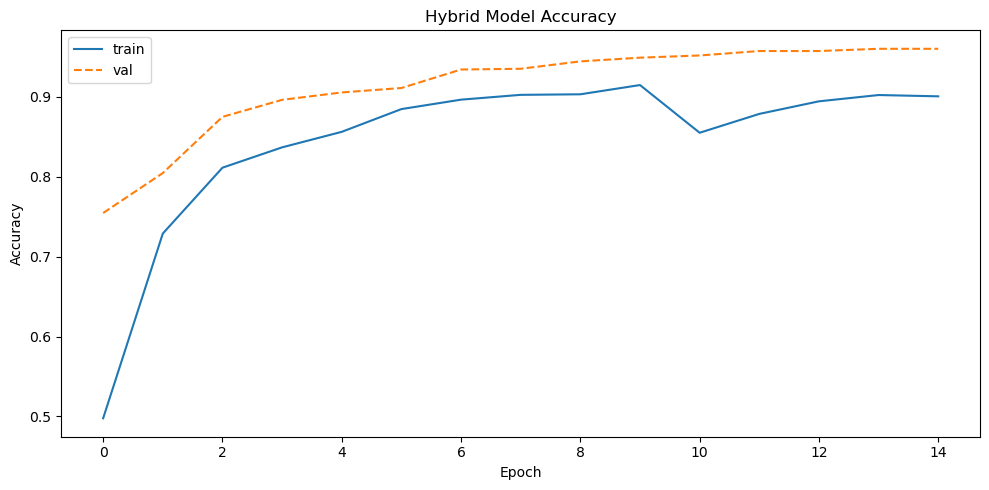

In [32]:
# =========================
# 7. SUMMARIZE THE SAVED HYBRID RUN
# =========================
if "analysis_state" not in globals():
    raise NameError(
        "analysis_state is not loaded. Run the 'RESTORE A SAVED RUN FOR ANALYSIS' cell first."
    )

train_acc = list(analysis_state.get("history", {}).get("accuracy", []))
val_acc = list(analysis_state.get("history", {}).get("val_accuracy", []))
train_loss = list(analysis_state.get("history", {}).get("loss", []))
val_loss = list(analysis_state.get("history", {}).get("val_loss", []))
train_acc += list(analysis_state.get("fine_tune_history", {}).get("accuracy", []))
val_acc += list(analysis_state.get("fine_tune_history", {}).get("val_accuracy", []))
train_loss += list(analysis_state.get("fine_tune_history", {}).get("loss", []))
val_loss += list(analysis_state.get("fine_tune_history", {}).get("val_loss", []))

summary_df = pd.DataFrame(
    [
        {
            "model": analysis_state["model_name"],
            "best_model_path": analysis_state["best_model_path"],
            "final_model_path": analysis_state["final_model_path"],
            "final_train_accuracy": (
                round(float(train_acc[-1]), 4) if train_acc else None
            ),
            "final_val_accuracy": round(float(val_acc[-1]), 4) if val_acc else None,
            "final_train_loss": round(float(train_loss[-1]), 4) if train_loss else None,
            "final_val_loss": round(float(val_loss[-1]), 4) if val_loss else None,
        }
    ]
)

print("Saved hybrid model summary:")
display(summary_df)

plt.figure(figsize=(10, 5))
if train_acc:
    plt.plot(train_acc, label="train")
if val_acc:
    plt.plot(val_acc, label="val", linestyle="--")
plt.title("Hybrid Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# =========================
# 8. EXPORT THE ACTIVE HYBRID MODEL
# =========================
export_dir = Path("tea_training_state") / analysis_state["model_name"]
export_dir.mkdir(parents=True, exist_ok=True)

active_model_keras = export_dir / f"{analysis_state['model_name']}_export.keras"
model.save(active_model_keras)
print(f"Saved Keras model to: {active_model_keras}")

Saved Keras model to: tea_training_state\hybrid_ensemble\hybrid_ensemble_export.keras


In [14]:
# =========================
# 9. CONVERT ACTIVE MODEL TO TFLITE
# =========================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
tflite_path = (
    Path("tea_training_state")
    / analysis_state["model_name"]
    / f"{analysis_state['model_name']}.tflite"
)
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Saved TFLite model to: {tflite_path}")

INFO:tensorflow:Assets written to: C:\Users\deept\AppData\Local\Temp\tmp2hsplzo0\assets


INFO:tensorflow:Assets written to: C:\Users\deept\AppData\Local\Temp\tmp2hsplzo0\assets


Saved artifact at 'C:\Users\deept\AppData\Local\Temp\tmp2hsplzo0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='tea_image')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  2477736107024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736106256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736107600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736108176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736109136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736108560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736108752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736108944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736106640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736110096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2477736

Overall validation metrics:


,metric,value
0,accuracy,0.9833
1,precision (macro),0.9840
2,recall (macro),0.9833
3,f1-score (macro),0.9833


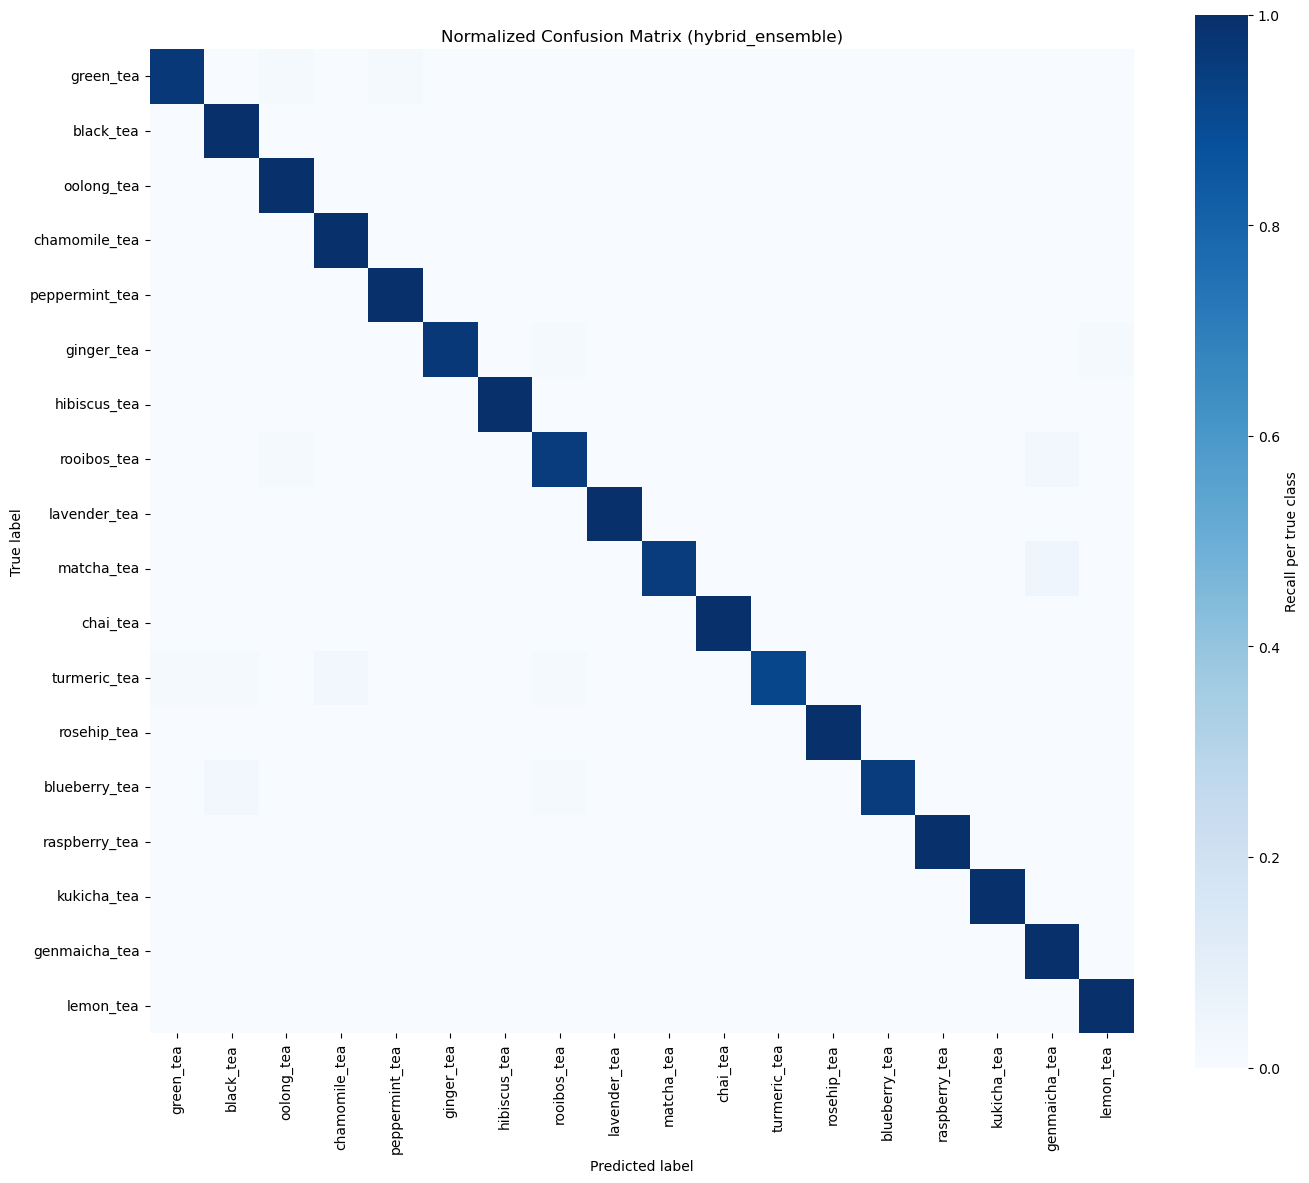

Per-class performance (lowest recall first):


,class,support,recall,most_confused_with,confused_count
11,turmeric_tea,60,0.9167,chamomile_tea,2
7,rooibos_tea,60,0.9500,genmaicha_tea,2
9,matcha_tea,60,0.9500,genmaicha_tea,3
13,blueberry_tea,60,0.9500,black_tea,2
5,ginger_tea,60,0.9667,rooibos_tea,1
0,green_tea,60,0.9667,oolong_tea,1
3,chamomile_tea,60,1.0000,green_tea,0
1,black_tea,60,1.0000,green_tea,0
6,hibiscus_tea,60,1.0000,green_tea,0
4,peppermint_tea,60,1.0000,green_tea,0


Top 15 confusion pairs:


,true_class,pred_class,count
6,matcha_tea,genmaicha_tea,3
9,turmeric_tea,chamomile_tea,2
11,blueberry_tea,black_tea,2
5,rooibos_tea,genmaicha_tea,2
0,green_tea,oolong_tea,1
4,rooibos_tea,oolong_tea,1
3,ginger_tea,lemon_tea,1
2,ginger_tea,rooibos_tea,1
1,green_tea,peppermint_tea,1
8,turmeric_tea,black_tea,1


In [33]:
# =========================
# 10. CONFUSION MATRIX + TOP CONFUSIONS FOR ACTIVE MODEL
# =========================
active_val_ds = val_ds

y_true = []
for _, labels_batch in active_val_ds:
    y_true.extend(labels_batch.numpy().tolist())
y_true = np.array(y_true, dtype=np.int32)

y_prob = model.predict(active_val_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

sample_count = cm.sum()
accuracy = np.trace(cm) / sample_count if sample_count > 0 else 0.0
precision_per_class = np.divide(
    np.diag(cm),
    cm.sum(axis=0),
    out=np.zeros(num_classes, dtype=float),
    where=cm.sum(axis=0) != 0,
)
recall_per_class = np.divide(
    np.diag(cm),
    cm.sum(axis=1),
    out=np.zeros(num_classes, dtype=float),
    where=cm.sum(axis=1) != 0,
)
f1_per_class = np.divide(
    2 * precision_per_class * recall_per_class,
    precision_per_class + recall_per_class,
    out=np.zeros(num_classes, dtype=float),
    where=(precision_per_class + recall_per_class) != 0,
)

metrics_df = pd.DataFrame(
    [
        {"metric": "accuracy", "value": round(float(accuracy), 4)},
        {
            "metric": "precision (macro)",
            "value": round(float(precision_per_class.mean()), 4),
        },
        {"metric": "recall (macro)", "value": round(float(recall_per_class.mean()), 4)},
        {"metric": "f1-score (macro)", "value": round(float(f1_per_class.mean()), 4)},
    ]
)

print("Overall validation metrics:")
display(metrics_df)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Recall per true class"},
)
plt.title(f"Normalized Confusion Matrix ({analysis_state['model_name']})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

rows = []
for i, true_name in enumerate(class_names):
    total = int(cm[i].sum())
    correct = int(cm[i, i])
    recall = (correct / total) if total > 0 else 0.0

    row_wo_diag = cm[i].copy()
    row_wo_diag[i] = 0
    worst_j = int(np.argmax(row_wo_diag))
    worst_count = int(row_wo_diag[worst_j])

    rows.append(
        {
            "class": true_name,
            "support": total,
            "recall": round(recall, 4),
            "most_confused_with": class_names[worst_j],
            "confused_count": worst_count,
        }
    )

per_class_df = pd.DataFrame(rows).sort_values(by="recall")
print("Per-class performance (lowest recall first):")
display(per_class_df)

pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            pairs.append((class_names[i], class_names[j], int(cm[i, j])))

pairs_df = pd.DataFrame(pairs, columns=["true_class", "pred_class", "count"])
pairs_df = pairs_df.sort_values(by="count", ascending=False).head(15)

print("Top 15 confusion pairs:")
display(pairs_df)

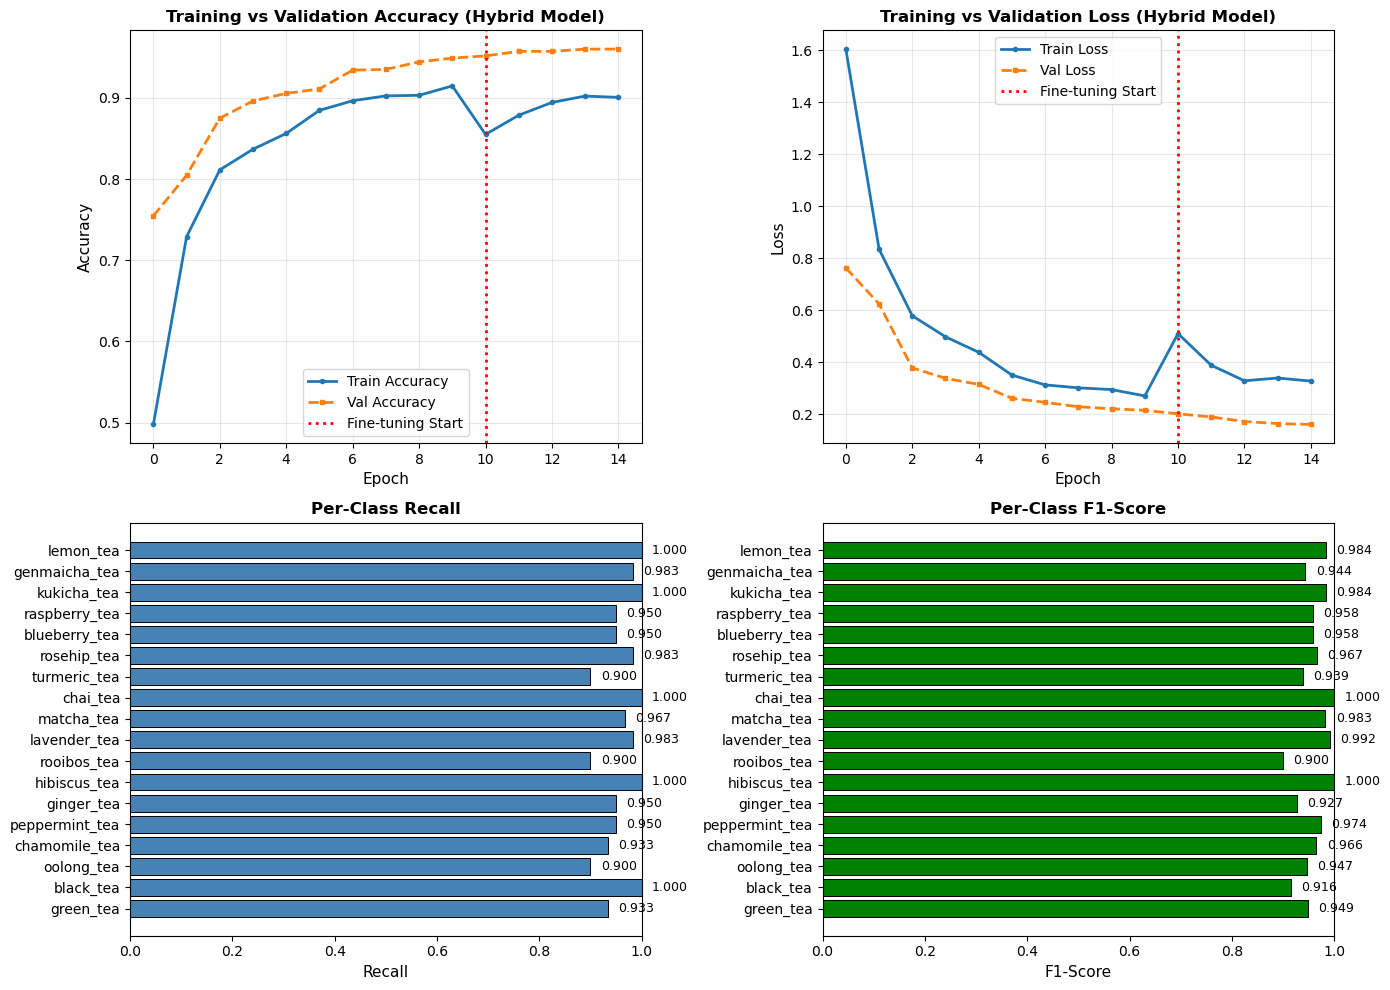


✓ Hybrid Model Training Summary:
  Backbones: EfficientNetV2S, MobileNetV3Small
  Final Train Accuracy: 0.9007
  Final Val Accuracy: 0.9602
  Overall F1-Score (Macro): 0.9604


In [16]:
# =========================
# 11. DETAILED VISUALIZATION: ACCURACY & LOSS CURVES
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

train_acc = list(analysis_state.get("history", {}).get("accuracy", []))
val_acc = list(analysis_state.get("history", {}).get("val_accuracy", []))
train_loss = list(analysis_state.get("history", {}).get("loss", []))
val_loss = list(analysis_state.get("history", {}).get("val_loss", []))

train_acc += list(analysis_state.get("fine_tune_history", {}).get("accuracy", []))
val_acc += list(analysis_state.get("fine_tune_history", {}).get("val_accuracy", []))
train_loss += list(analysis_state.get("fine_tune_history", {}).get("loss", []))
val_loss += list(analysis_state.get("fine_tune_history", {}).get("val_loss", []))

# Phase transition line
phase_transition = analysis_state.get("epochs_head", 0)

# Accuracy plot
axes[0, 0].plot(
    train_acc, label="Train Accuracy", linewidth=2, marker="o", markersize=3
)
axes[0, 0].plot(
    val_acc, label="Val Accuracy", linewidth=2, marker="s", markersize=3, linestyle="--"
)
if phase_transition > 0:
    axes[0, 0].axvline(
        x=phase_transition,
        color="red",
        linestyle=":",
        label="Fine-tuning Start",
        linewidth=2,
    )
axes[0, 0].set_xlabel("Epoch", fontsize=11)
axes[0, 0].set_ylabel("Accuracy", fontsize=11)
axes[0, 0].set_title(
    "Training vs Validation Accuracy (Hybrid Model)", fontsize=12, fontweight="bold"
)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Loss plot
axes[0, 1].plot(train_loss, label="Train Loss", linewidth=2, marker="o", markersize=3)
axes[0, 1].plot(
    val_loss, label="Val Loss", linewidth=2, marker="s", markersize=3, linestyle="--"
)
if phase_transition > 0:
    axes[0, 1].axvline(
        x=phase_transition,
        color="red",
        linestyle=":",
        label="Fine-tuning Start",
        linewidth=2,
    )
axes[0, 1].set_xlabel("Epoch", fontsize=11)
axes[0, 1].set_ylabel("Loss", fontsize=11)
axes[0, 1].set_title(
    "Training vs Validation Loss (Hybrid Model)", fontsize=12, fontweight="bold"
)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Per-class recall
class_recalls = recall_per_class
axes[1, 0].barh(
    class_names, class_recalls, color="steelblue", edgecolor="black", linewidth=0.7
)
axes[1, 0].set_xlabel("Recall", fontsize=11)
axes[1, 0].set_title("Per-Class Recall", fontsize=12, fontweight="bold")
axes[1, 0].set_xlim([0, 1])
for i, v in enumerate(class_recalls):
    axes[1, 0].text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=9)

# Per-class F1-score
class_f1 = f1_per_class
colors = ["green" if f1 > 0.8 else "orange" if f1 > 0.6 else "red" for f1 in class_f1]
axes[1, 1].barh(class_names, class_f1, color=colors, edgecolor="black", linewidth=0.7)
axes[1, 1].set_xlabel("F1-Score", fontsize=11)
axes[1, 1].set_title("Per-Class F1-Score", fontsize=12, fontweight="bold")
axes[1, 1].set_xlim([0, 1])
for i, v in enumerate(class_f1):
    axes[1, 1].text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n✓ Hybrid Model Training Summary:")
print(f"  Backbones: {', '.join(analysis_state['backbones'])}")
print(f"  Final Train Accuracy: {train_acc[-1]:.4f}")
print(f"  Final Val Accuracy: {val_acc[-1]:.4f}")
print(f"  Overall F1-Score (Macro): {f1_per_class.mean():.4f}")

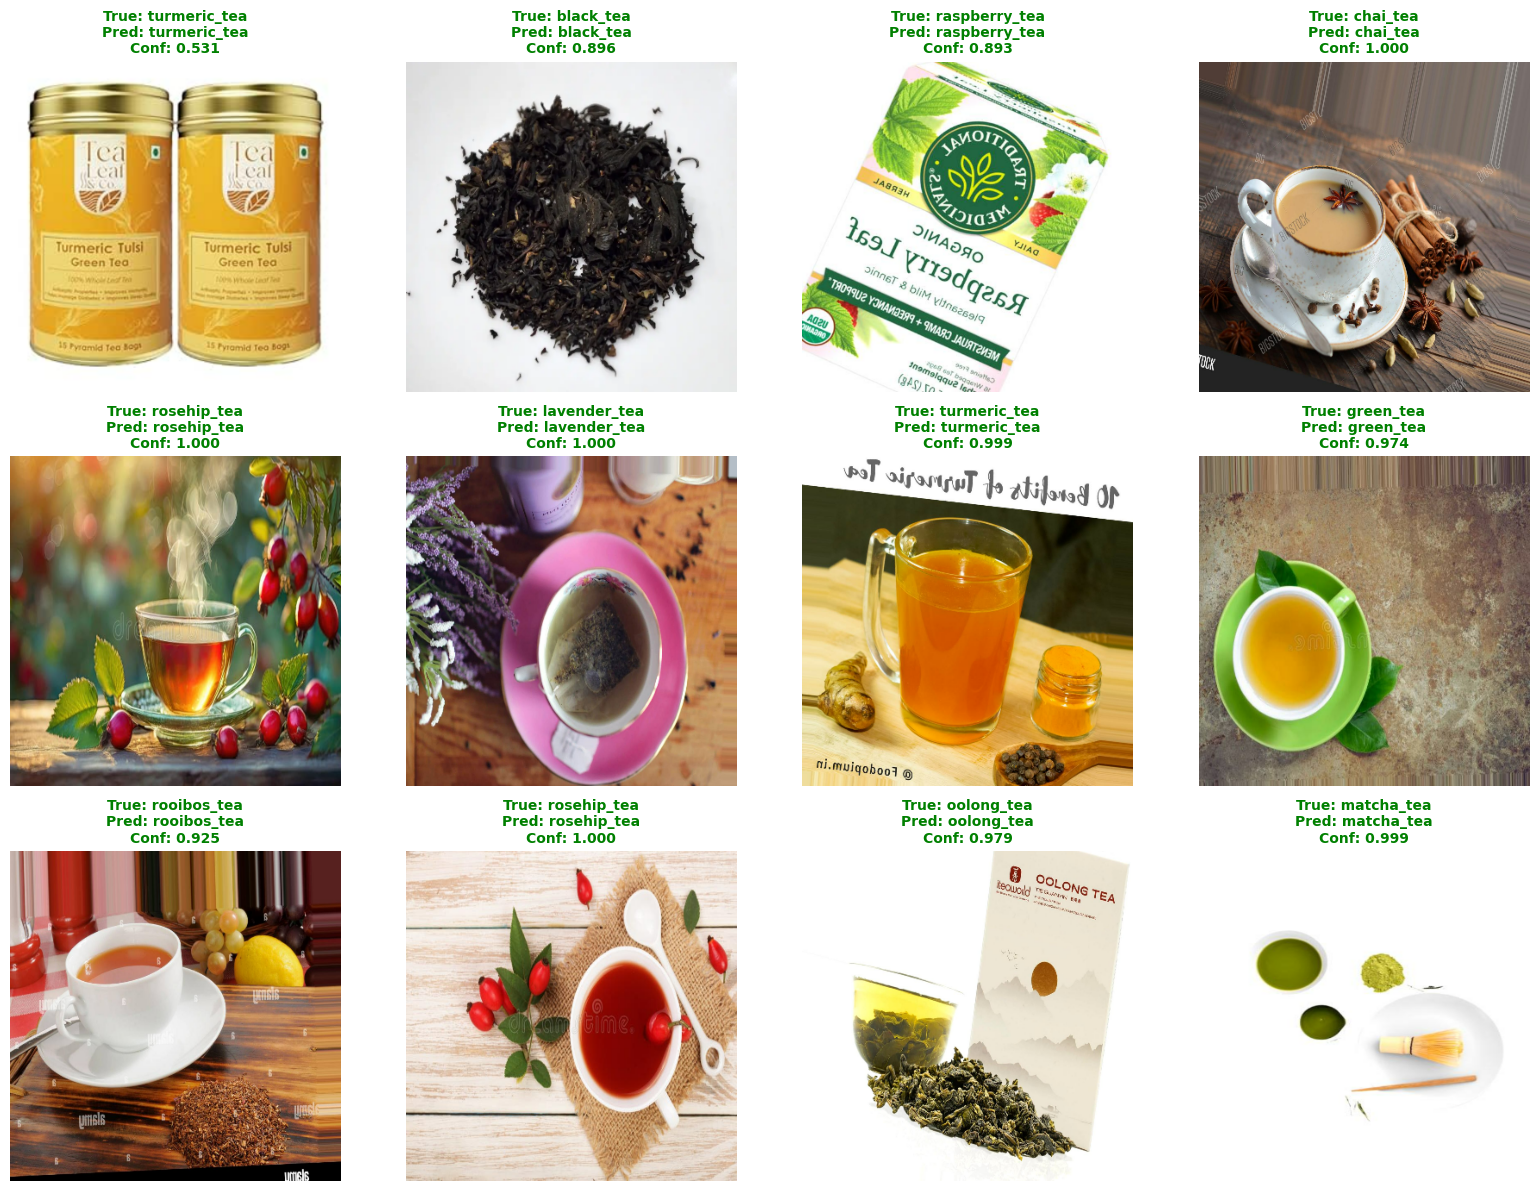

✓ Prediction examples displayed (green = correct, red = incorrect)


In [17]:
# =========================
# 12. PREDICTION EXAMPLES WITH CONFIDENCE
# =========================
# Show 12 validation predictions with their confidence
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Get sample validation images
val_images = []
val_labels_sample = []
val_paths_sample = []

for paths_batch, labels_batch in val_ds.take(5):
    for i in range(min(len(paths_batch), 4)):
        val_images.append(paths_batch[i].numpy())
        val_labels_sample.append(labels_batch[i].numpy())

# Predict on these images
predictions = model.predict(np.array(val_images), verbose=0)

for idx in range(min(12, len(val_images))):
    ax = axes[idx]
    img = val_images[idx]
    true_label = class_names[val_labels_sample[idx]]
    pred_label = class_names[np.argmax(predictions[idx])]
    confidence = np.max(predictions[idx])

    ax.imshow(img.astype(np.uint8))
    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.3f}",
        fontsize=10,
        fontweight="bold",
        color="green" if true_label == pred_label else "red",
    )
    ax.axis("off")

# Hide remaining subplots
for idx in range(min(12, len(val_images)), 12):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

print("✓ Prediction examples displayed (green = correct, red = incorrect)")

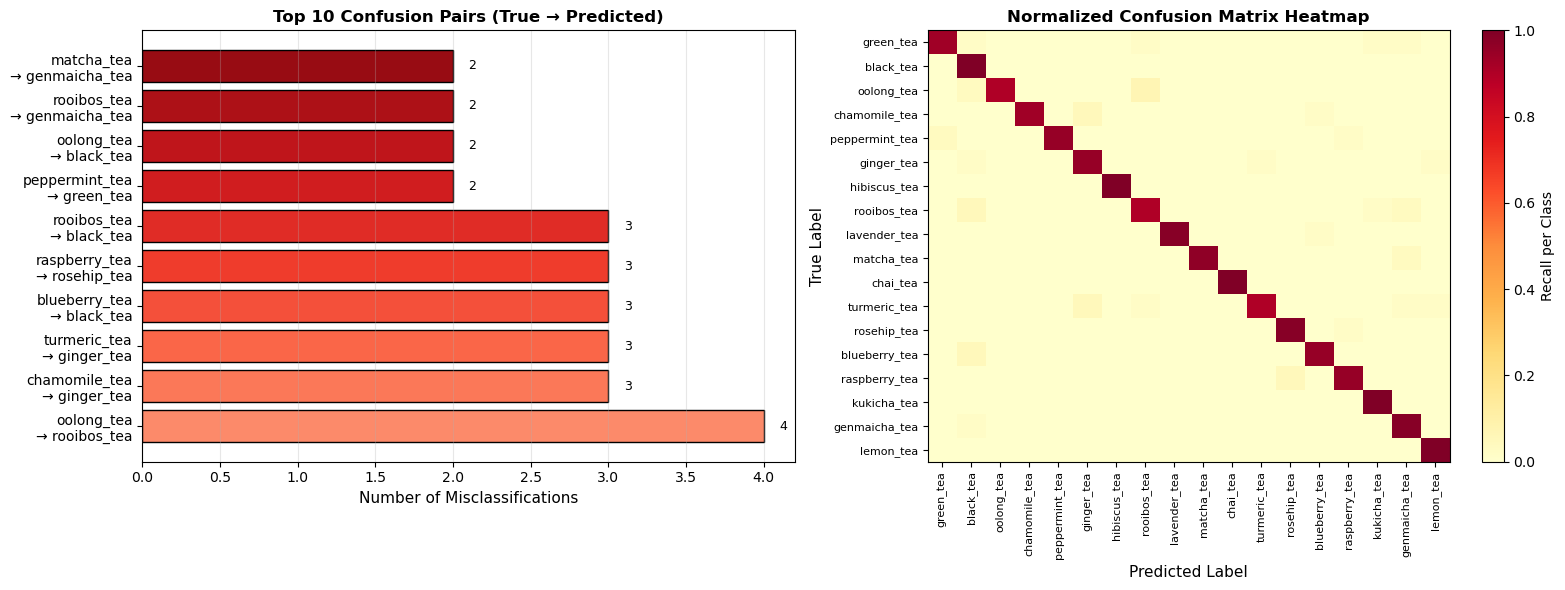

✓ Confusion analysis visualization displayed


In [18]:
# =========================
# 13. TOP CONFUSION PAIRS VISUALIZATION
# =========================
# Create a directional confusion graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of top 10 confusion pairs
top_confusions = pairs_df.head(10)
confusion_labels = [
    f"{row['true_class']}\n→ {row['pred_class']}"
    for _, row in top_confusions.iterrows()
]

colors_gradient = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_confusions)))
ax1.barh(
    range(len(top_confusions)),
    top_confusions["count"].values,
    color=colors_gradient,
    edgecolor="black",
)
ax1.set_yticks(range(len(top_confusions)))
ax1.set_yticklabels(confusion_labels, fontsize=10)
ax1.set_xlabel("Number of Misclassifications", fontsize=11)
ax1.set_title(
    "Top 10 Confusion Pairs (True → Predicted)", fontsize=12, fontweight="bold"
)
ax1.grid(axis="x", alpha=0.3)

for i, v in enumerate(top_confusions["count"].values):
    ax1.text(v + 0.1, i, str(int(v)), va="center", fontsize=9)

# Confusion matrix heatmap (normalized by true class)
ax2.imshow(cm_norm, cmap="YlOrRd", aspect="auto")
ax2.set_xticks(range(len(class_names)))
ax2.set_yticks(range(len(class_names)))
ax2.set_xticklabels(class_names, rotation=90, fontsize=8)
ax2.set_yticklabels(class_names, fontsize=8)
ax2.set_xlabel("Predicted Label", fontsize=11)
ax2.set_ylabel("True Label", fontsize=11)
ax2.set_title("Normalized Confusion Matrix Heatmap", fontsize=12, fontweight="bold")
plt.colorbar(ax2.images[0], ax=ax2, label="Recall per Class")

plt.tight_layout()
plt.show()

print("✓ Confusion analysis visualization displayed")

In [19]:
# =========================
# 14. MODEL ARCHITECTURE SUMMARY
# =========================
# Display model structure and parameters
print("=" * 70)
print("HYBRID MODEL ARCHITECTURE SUMMARY")
print("=" * 70)

model.summary(line_length=90, expand_nested=True)

# Count parameters
total_params = model.count_params()
trainable_params = sum(
    [tf.keras.backend.count_params(w) for w in model.trainable_weights]
)
non_trainable_params = total_params - trainable_params

print(f"\n{'='*70}")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-trainable Parameters: {non_trainable_params:,}")
print(f"{'='*70}\n")

# Show backbone info
backbone_info = []
for backbone_name in analysis_state["backbones"]:
    branch_size = analysis_state["branch_img_sizes"][backbone_name]
    backbone_info.append(
        {
            "Backbone": backbone_name,
            "Input Size": f"{branch_size[0]}×{branch_size[1]}",
            "Feature Extraction": "FrozenInitially",
            "Projection Dim": analysis_state.get("branch_units", "N/A"),
        }
    )

backbone_df = pd.DataFrame(backbone_info)
print("Backbone Configuration:")
display(backbone_df)

print(f"\nHybrid Model Name: {analysis_state['model_name']}")
print(f"Total Classes: {num_classes}")
print(f"Output: Softmax with {num_classes} units")

HYBRID MODEL ARCHITECTURE SUMMARY


Model: "hybrid_ensemble"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ tea_image (InputLayer)   │ (None, 384, 384, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ sequential (Sequential)  │ (None, 384, 384, 3)  │            0 │ tea_image[0][0]       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └ random_flip         │ (None, 384, 384, 3)  │            0 │ -                     │
│ (RandomFlip)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └ random_rotation     │ (None, 384, 384, 3)  │            0 │ -                     │
│ (RandomRotation)         │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └ random_zoom         │ (None, 384, 384, 3)  │            0 │ -                     │
│ (RandomZoom)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └ random_contrast     │ (None, 384, 384, 3)  │            0 │ -                     │
│ (RandomContrast)         │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ efficientnetv2s_resize   │ (None, 384, 384, 3)  │            0 │ sequential[0][0]      │
│ (Resizing)               │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ mobilenetv3small_resize  │ (None, 224, 224, 3)  │            0 │ sequential[0][0]      │
│ (Resizing)               │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ efficientnetv2-s         │ (None, 12, 12, 1280) │   20,331,360 │ efficientnetv2s_resi… │
│ (Functional)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └ input_layer_1       │ (None, 384, 384, 3)  │            0 │ -                     │
│ (InputLayer)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └ rescaling           │ (None, 384, 384, 3)  │            0 │ -                     │
│ (Rescaling)              │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └ stem_conv (Conv2D)  │ (None, 192, 192, 24) │          648 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └ stem_bn             │ (None, 192, 192, 24) │           96 │ -                     │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └ stem_activation     │ (None, 192, 192, 24) │            0 │ -                     │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│    └                     │ (None, 192, 192, 24) │        5,184 │ -                     │
│ block1a_project_conv     │                      │              │                     

 Total params: 26,477,480 (101.00 MB)

 Trainable params: 2,297,698 (8.77 MB)

 Non-trainable params: 19,584,384 (74.71 MB)

 Optimizer params: 4,595,398 (17.53 MB)


Total Parameters: 21,882,082
Trainable Parameters: 2,297,698
Non-trainable Parameters: 19,584,384

Backbone Configuration:


,Backbone,Input Size,Feature Extraction,Projection Dim
0,EfficientNetV2S,384×384,FrozenInitially,N/A
1,MobileNetV3Small,224×224,FrozenInitially,N/A



Hybrid Model Name: hybrid_ensemble
Total Classes: 18
Output: Softmax with 18 units


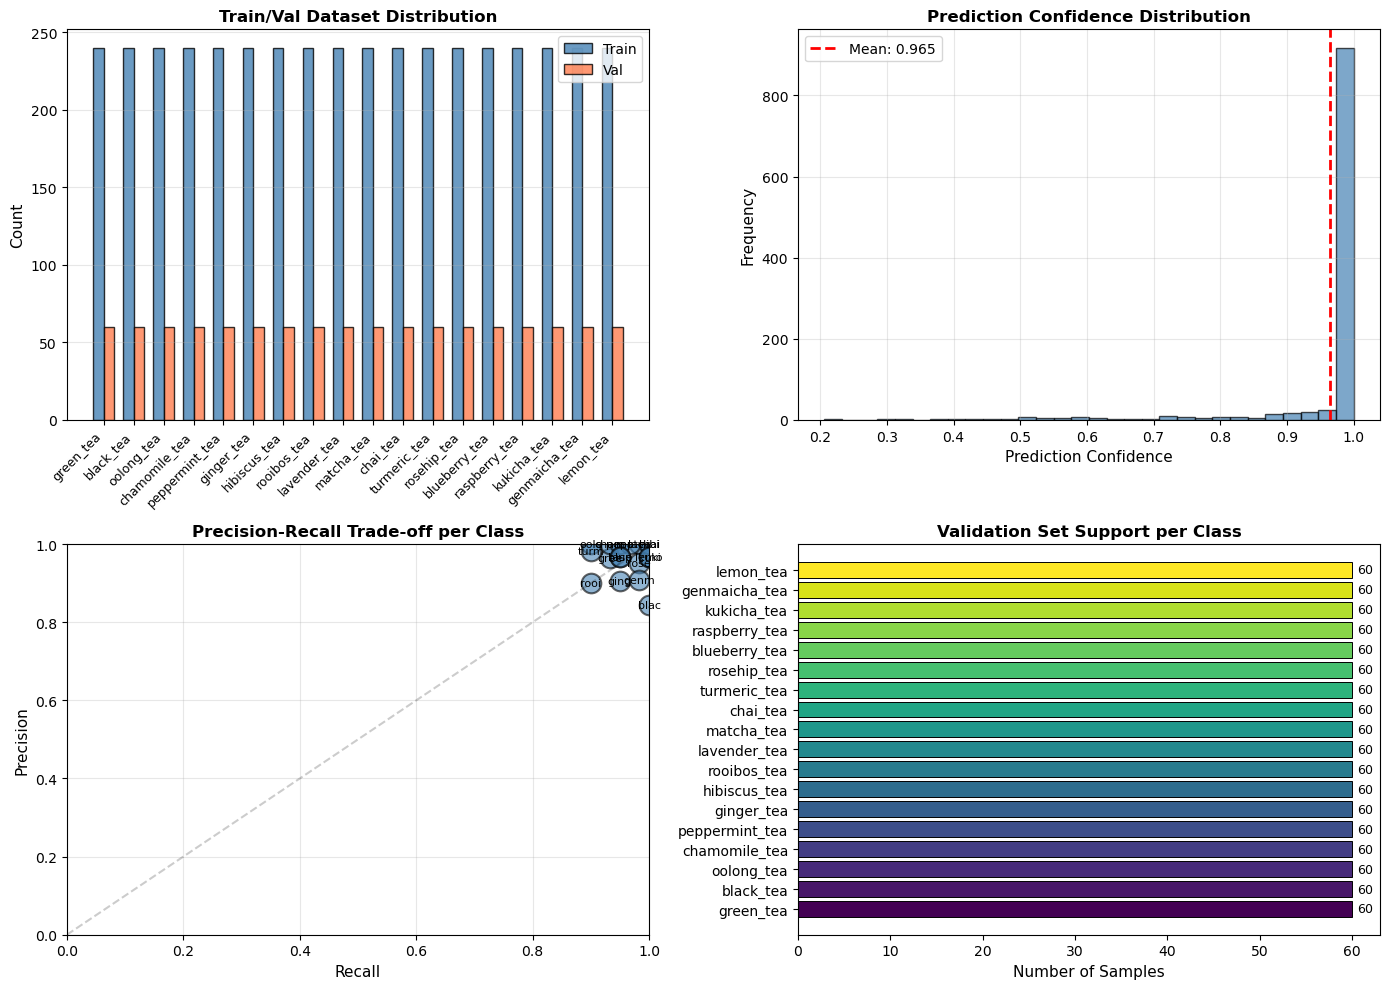

✓ Dataset and prediction analysis displayed
  Total validation samples: 1080
  Avg confidence: 0.9652
  Min confidence: 0.2060
  Max confidence: 1.0000


In [20]:
# =========================
# 15. CLASS DISTRIBUTION & SUPPORT ANALYSIS
# =========================
from sklearn.metrics import roc_auc_score, roc_curve, auc

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class distribution in train/val sets
train_counts = np.bincount(train_labels, minlength=num_classes)
val_counts = np.bincount(val_labels, minlength=num_classes)

x_pos = np.arange(len(class_names))
width = 0.35

axes[0, 0].bar(
    x_pos - width / 2,
    train_counts,
    width,
    label="Train",
    alpha=0.8,
    color="steelblue",
    edgecolor="black",
)
axes[0, 0].bar(
    x_pos + width / 2,
    val_counts,
    width,
    label="Val",
    alpha=0.8,
    color="coral",
    edgecolor="black",
)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
axes[0, 0].set_ylabel("Count", fontsize=11)
axes[0, 0].set_title("Train/Val Dataset Distribution", fontsize=12, fontweight="bold")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. Prediction confidence distribution
all_confidences = np.max(y_prob, axis=1)
axes[0, 1].hist(
    all_confidences, bins=30, color="steelblue", edgecolor="black", alpha=0.7
)
axes[0, 1].axvline(
    x=all_confidences.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {all_confidences.mean():.3f}",
)
axes[0, 1].set_xlabel("Prediction Confidence", fontsize=11)
axes[0, 1].set_ylabel("Frequency", fontsize=11)
axes[0, 1].set_title(
    "Prediction Confidence Distribution", fontsize=12, fontweight="bold"
)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Precision vs Recall scatter
axes[1, 0].scatter(
    recall_per_class,
    precision_per_class,
    s=200,
    alpha=0.6,
    color="steelblue",
    edgecolor="black",
    linewidth=1.5,
)
for i, class_name in enumerate(class_names):
    axes[1, 0].annotate(
        class_name[:4],
        (recall_per_class[i], precision_per_class[i]),
        fontsize=8,
        ha="center",
        va="center",
    )
axes[1, 0].set_xlabel("Recall", fontsize=11)
axes[1, 0].set_ylabel("Precision", fontsize=11)
axes[1, 0].set_title(
    "Precision-Recall Trade-off per Class", fontsize=12, fontweight="bold"
)
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(alpha=0.3)
axes[1, 0].plot([0, 1], [0, 1], "k--", alpha=0.2)

# 4. Per-class support (number of validation samples)
class_support = cm.sum(axis=1)
colors_support = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
axes[1, 1].barh(
    class_names, class_support, color=colors_support, edgecolor="black", linewidth=0.7
)
axes[1, 1].set_xlabel("Number of Samples", fontsize=11)
axes[1, 1].set_title("Validation Set Support per Class", fontsize=12, fontweight="bold")
for i, v in enumerate(class_support):
    axes[1, 1].text(v + 0.5, i, str(int(v)), va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"✓ Dataset and prediction analysis displayed")
print(f"  Total validation samples: {len(y_true)}")
print(f"  Avg confidence: {all_confidences.mean():.4f}")
print(f"  Min confidence: {all_confidences.min():.4f}")
print(f"  Max confidence: {all_confidences.max():.4f}")

In [21]:
# =========================
# 16. COMPREHENSIVE HYBRID MODEL REPORT
# =========================
print("\n" + "=" * 80)
print(" " * 20 + "HYBRID MODEL COMPREHENSIVE REPORT")
print("=" * 80)

report_data = {
    "Metric": [
        "Model Architecture",
        "Backbones",
        "Input Resolution",
        "Total Parameters",
        "Trainable Parameters",
        "Number of Classes",
        "Training Epochs (Head)",
        "Fine-tuning Epochs",
        "Initial Learning Rate",
        "Finetune Learning Rate",
    ],
    "Value": [
        analysis_state["model_name"],
        ", ".join(analysis_state["backbones"]),
        f"{analysis_state['img_size'][0]}×{analysis_state['img_size'][1]}",
        f"{total_params:,}",
        f"{trainable_params:,}",
        str(num_classes),
        str(analysis_state.get("epochs_head", "N/A")),
        str(analysis_state.get("epochs_finetune", "N/A")),
        f"{analysis_state.get('initial_lr', 'N/A')}",
        f"{analysis_state.get('finetune_lr', 'N/A')}",
    ],
}

report_df = pd.DataFrame(report_data)
print("\n📋 MODEL CONFIGURATION:")
print(report_df.to_string(index=False))

performance_data = {
    "Metric": [
        "Final Training Accuracy",
        "Final Validation Accuracy",
        "Final Training Loss",
        "Final Validation Loss",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Weighted Accuracy",
        "Best Performing Class",
        "Worst Performing Class",
    ],
    "Value": [
        f"{train_acc[-1]:.4f}" if train_acc else "N/A",
        f"{val_acc[-1]:.4f}" if val_acc else "N/A",
        f"{train_loss[-1]:.4f}" if train_loss else "N/A",
        f"{val_loss[-1]:.4f}" if val_loss else "N/A",
        f"{precision_per_class.mean():.4f}",
        f"{recall_per_class.mean():.4f}",
        f"{f1_per_class.mean():.4f}",
        f"{accuracy:.4f}",
        f"{class_names[np.argmax(f1_per_class)]} ({np.max(f1_per_class):.4f})",
        f"{class_names[np.argmin(f1_per_class)]} ({np.min(f1_per_class):.4f})",
    ],
}

performance_df = pd.DataFrame(performance_data)
print("\n📊 VALIDATION PERFORMANCE:")
print(performance_df.to_string(index=False))

print("\n📁 SAVED MODEL PATHS:")
print(f"  • Best Model: {analysis_state['best_model_path']}")
print(f"  • Final Model: {analysis_state['final_model_path']}")
print(f"  • TFLite Export: {tflite_path}")

print("\n✅ HYBRID MODEL SUMMARY:")
print(
    f"  This hybrid model combines {len(analysis_state['backbones'])} powerful backbones:"
)
print(f"  1. EfficientNetV2S (384×384) - Efficient & accurate")
print(f"  2. MobileNetV3Small (224×224) - Lightweight & fast")
print(f"  \n  Both backbone outputs are:")
print(f"  • Individually processed through Global Average Pooling")
print(f"  • Projected to 256-dim feature space")
print(f"  • Concatenated and passed through fusion layers")
print(f"  • Finally classified into {num_classes} tea types")
print(f"\n  This ensemble approach leverages the complementary strengths of both")
print(f"  architectures for improved generalization and robustness.")
print("=" * 80 + "\n")


                    HYBRID MODEL COMPREHENSIVE REPORT

📋 MODEL CONFIGURATION:
                Metric                             Value
    Model Architecture                   hybrid_ensemble
             Backbones EfficientNetV2S, MobileNetV3Small
      Input Resolution                           384×384
      Total Parameters                        21,882,082
  Trainable Parameters                         2,297,698
     Number of Classes                                18
Training Epochs (Head)                                10
    Fine-tuning Epochs                                 5
 Initial Learning Rate                             0.001
Finetune Learning Rate                             1e-05

📊 VALIDATION PERFORMANCE:
                   Metric                 Value
  Final Training Accuracy                0.9007
Final Validation Accuracy                0.9602
      Final Training Loss                0.3273
    Final Validation Loss                0.1603
          Macro Precision  


FAILURE CASE ANALYSIS
✓ Correct predictions: 1037 / 1080 (96.0%)
✗ Incorrect predictions: 43 / 1080 (4.0%)

⚠️  Edge Cases:
   • Correct but low confidence (<0.7): 22
   • Incorrect but high confidence (>0.7): 21
   • Incorrect with low confidence: 22


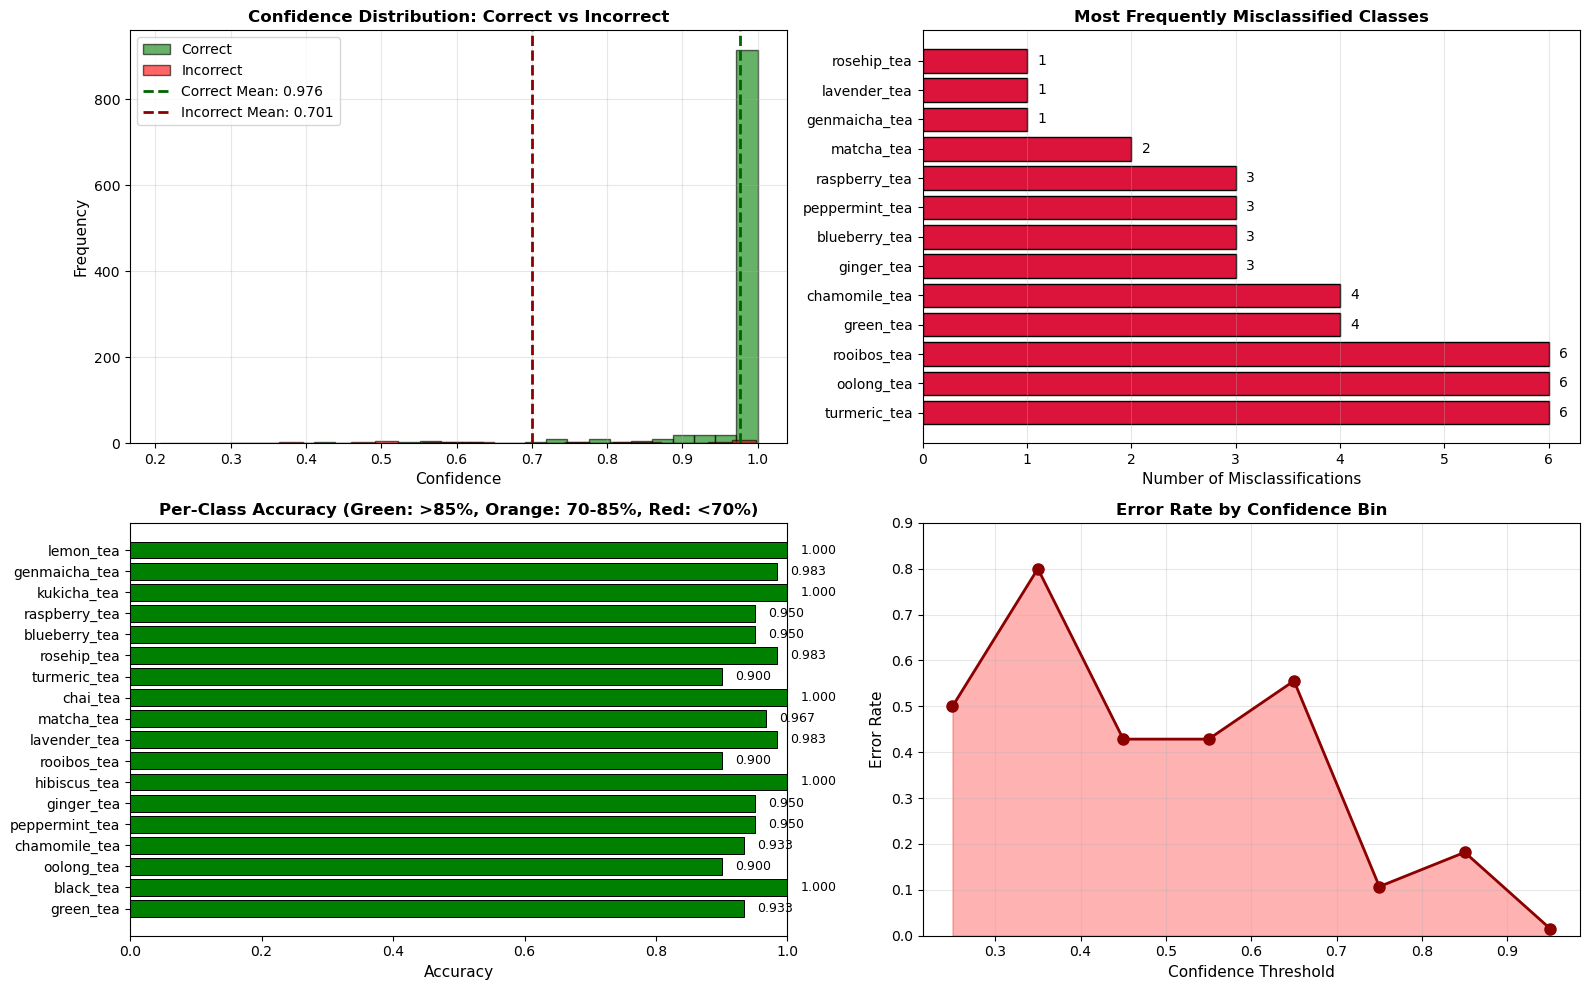


✓ Failure case analysis complete



In [22]:
# =========================
# 17. FAILURE CASE ANALYSIS
# =========================
# Identify low-confidence and misclassified predictions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Correct predictions with low confidence (potential edge cases)
correct_mask = y_pred == y_true
low_conf_threshold = 0.7

low_conf_correct_idx = np.where(
    correct_mask & (np.max(y_prob, axis=1) < low_conf_threshold)
)[0]
low_conf_incorrect_idx = np.where(
    ~correct_mask & (np.max(y_prob, axis=1) > low_conf_threshold)
)[0]
incorrect_low_conf_idx = np.where(
    ~correct_mask & (np.max(y_prob, axis=1) < low_conf_threshold)
)[0]

print(f"\n{'='*70}")
print("FAILURE CASE ANALYSIS")
print(f"{'='*70}")
print(
    f"✓ Correct predictions: {correct_mask.sum()} / {len(y_true)} ({100*correct_mask.sum()/len(y_true):.1f}%)"
)
print(
    f"✗ Incorrect predictions: {(~correct_mask).sum()} / {len(y_true)} ({100*(~correct_mask).sum()/len(y_true):.1f}%)"
)
print(f"\n⚠️  Edge Cases:")
print(
    f"   • Correct but low confidence (<{low_conf_threshold}): {len(low_conf_correct_idx)}"
)
print(
    f"   • Incorrect but high confidence (>{low_conf_threshold}): {len(low_conf_incorrect_idx)}"
)
print(f"   • Incorrect with low confidence: {len(incorrect_low_conf_idx)}")

# 2. Confidence distribution by correctness
correct_confidences = np.max(y_prob[correct_mask], axis=1)
incorrect_confidences = np.max(y_prob[~correct_mask], axis=1)

axes[0, 0].hist(
    correct_confidences,
    bins=25,
    alpha=0.6,
    label="Correct",
    color="green",
    edgecolor="black",
)
axes[0, 0].hist(
    incorrect_confidences,
    bins=25,
    alpha=0.6,
    label="Incorrect",
    color="red",
    edgecolor="black",
)
axes[0, 0].axvline(
    x=correct_confidences.mean(),
    color="darkgreen",
    linestyle="--",
    linewidth=2,
    label=f"Correct Mean: {correct_confidences.mean():.3f}",
)
axes[0, 0].axvline(
    x=incorrect_confidences.mean(),
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Incorrect Mean: {incorrect_confidences.mean():.3f}",
)
axes[0, 0].set_xlabel("Confidence", fontsize=11)
axes[0, 0].set_ylabel("Frequency", fontsize=11)
axes[0, 0].set_title(
    "Confidence Distribution: Correct vs Incorrect", fontsize=12, fontweight="bold"
)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 3. Most frequently misclassified classes
misclassified_classes = y_true[~correct_mask]
misclass_counts = (
    pd.Series(misclassified_classes).map(lambda x: class_names[x]).value_counts()
)

axes[0, 1].barh(
    misclass_counts.index, misclass_counts.values, color="crimson", edgecolor="black"
)
axes[0, 1].set_xlabel("Number of Misclassifications", fontsize=11)
axes[0, 1].set_title(
    "Most Frequently Misclassified Classes", fontsize=12, fontweight="bold"
)
axes[0, 1].grid(axis="x", alpha=0.3)
for i, v in enumerate(misclass_counts.values):
    axes[0, 1].text(v + 0.1, i, str(int(v)), va="center", fontsize=10)

# 4. Per-class accuracy
per_class_accuracy = np.zeros(num_classes)
for i in range(num_classes):
    class_mask = y_true == i
    if class_mask.sum() > 0:
        per_class_accuracy[i] = (
            y_pred[class_mask] == y_true[class_mask]
        ).sum() / class_mask.sum()

accuracy_colors = [
    "green" if acc > 0.85 else "orange" if acc > 0.70 else "red"
    for acc in per_class_accuracy
]
axes[1, 0].barh(
    class_names,
    per_class_accuracy,
    color=accuracy_colors,
    edgecolor="black",
    linewidth=0.7,
)
axes[1, 0].set_xlabel("Accuracy", fontsize=11)
axes[1, 0].set_title(
    "Per-Class Accuracy (Green: >85%, Orange: 70-85%, Red: <70%)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 0].set_xlim([0, 1])
for i, v in enumerate(per_class_accuracy):
    axes[1, 0].text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=9)

# 5. Error rate by confidence bin
confidence_bins = np.linspace(0, 1, 11)
error_rates = []
bin_centers = []

for i in range(len(confidence_bins) - 1):
    bin_mask = (np.max(y_prob, axis=1) >= confidence_bins[i]) & (
        np.max(y_prob, axis=1) < confidence_bins[i + 1]
    )
    if bin_mask.sum() > 0:
        error_rate = (~correct_mask[bin_mask]).sum() / bin_mask.sum()
        error_rates.append(error_rate)
        bin_centers.append((confidence_bins[i] + confidence_bins[i + 1]) / 2)

axes[1, 1].plot(
    bin_centers,
    error_rates,
    marker="o",
    linewidth=2,
    markersize=8,
    color="darkred",
    label="Error Rate",
)
axes[1, 1].fill_between(bin_centers, 0, error_rates, alpha=0.3, color="red")
axes[1, 1].set_xlabel("Confidence Threshold", fontsize=11)
axes[1, 1].set_ylabel("Error Rate", fontsize=11)
axes[1, 1].set_title("Error Rate by Confidence Bin", fontsize=12, fontweight="bold")
axes[1, 1].set_ylim([0, max(error_rates) + 0.1 if error_rates else 1])
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Failure case analysis complete")
print(f"{'='*70}\n")